In [2]:
from enum import Enum
import os
from datetime import datetime, timedelta

import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path
import pygame
from scipy.io import loadmat
from scipy.special import softmax
from scipy.stats import binomtest
import scipy
import statsmodels.api as sm
import statsmodels.formula.api as smf

import gymnasium as gym
from gymnasium import spaces

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch

from scipy.sparse.csgraph import shortest_path
from sklearn.mixture import GaussianMixture
from sklearn.mixture import BayesianGaussianMixture

import networkx as nx
from collections import defaultdict, Counter
import itertools
import warnings
warnings.filterwarnings("ignore")

from grid_distance_viz import plot_all_targets, _draw_graph_edges

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
# plotting params

mpl.rcParams.update({
    # Figure
    'figure.figsize': (6, 4),
    'figure.dpi': 100,
    'savefig.dpi': 300,

    # Fonts
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,

    # Axes
    'axes.linewidth': 1,
    'axes.grid': False,

    # Ticks
    'xtick.major.size': 4,
    'ytick.major.size': 4,
    'xtick.major.width': 1,
    'ytick.major.width': 1,
    'xtick.direction': 'out',
    'ytick.direction': 'out',

    # Lines
    'lines.linewidth': 2,
    'lines.markersize': 6,

    # Legend
    'legend.frameon': False,

    # Saving
    'savefig.bbox': 'tight'
})

### Create graph G

In [4]:
edges = [
    (1,2), (2,3), (2,6), (3,4), (4,8),
    (5,9), (6,7), (6,10), (7,8), (7,11),
    (8,12), (9,10), (9,13), (10,11), (10,14),
    (11,15), (14,15), (15,16)
]

G = nx.Graph()
G.add_edges_from((u-1, v-1) for u, v in edges)  # 0-based indexing

In [5]:
def closer_neighbors(G, current, target):
    """Return neighbors of current that are one step closer to target."""
    try:
    
        d_current = nx.shortest_path_length(G, current, target)
        return np.array([nbr for nbr in G.neighbors(current)
                    if nx.shortest_path_length(G, nbr, target) < d_current])

    except Exception:
        return np.nan

In [6]:
def edge2action(G, n1, n2):
    """
    Parameters
    ----------
    G : networkx.Graph
    n1 : int
        Current node (0-based).
    n2 : int or array-like
        Destination node(s) (0-based).

    Returns
    -------
    action : ndarray, shape (4,)
        [left, right, down, up]
        1 = selected/correct action
        0 = valid but not selected
        NaN = invalid action
    """
    action = np.full(4, np.nan)

    # Mark all valid actions as 0
    for neigh in G.neighbors(n1):
        diff = neigh - n1
        if diff == -1:
            action[0] = 0
        elif diff == 1:
            action[1] = 0
        elif diff == 4:
            action[2] = 0
        elif diff == -4:
            action[3] = 0

    # Mark selected action(s) as 1
    for dest in np.atleast_1d(n2):
        diff = dest - n1
        if diff == -1:
            action[0] = 1
        elif diff == 1:
            action[1] = 1
        elif diff == 4:
            action[2] = 1
        elif diff == -4:
            action[3] = 1

    return action

# Data

### Load and prepare data

In [7]:
FIGDIR = 'D:/Newworld/Figure/'

In [44]:
start = datetime.strptime('260714', '%y%m%d')
end = datetime.strptime('260725', '%y%m%d')

all_dates = []
d = start
while d <= end:
    all_dates.append(d.strftime('%y%m%d'))
    d += timedelta(days=1)

# only keep dates where the file actually exists
dates = [d for d in all_dates if os.path.exists(f'D:/Newworld/Data/London_{d}.mat')]
beh = pd.DataFrame()

for date in dates:
    mat = loadmat(f'D:/Newworld/Data/London_{date}.mat', simplify_cells=True)
    temp = pd.DataFrame(mat['behavior'])
    temp = temp[temp.instruct==0]
    temp['BlockNumber'] = (temp['target_room'] != temp['target_room'].shift()).cumsum()
    prev_target = (
    temp.groupby('BlockNumber')['target_room']
        .last()
        .shift()
    )
    
    # Assign to every row
    temp['previous_target_room'] = temp['BlockNumber'].map(prev_target)
    temp.insert(0, 'Session', date)
    beh = pd.concat([beh,temp])

beh.reset_index(inplace=True,drop=True)
beh['target'] = beh.target_room - 1
beh['start'] = beh.start_room - 1
beh['current'] = beh.current_room - 1

nav = beh[beh.start!=beh.target].copy()
nav['success'] = (nav['TrialError'] == 0) * 1
room_seq = nav.groupby(['Session','Trial','target','start'])['current'].agg(list).reset_index(name='rooms')

nav_trial = nav[nav.step==1].copy()
flash_trial = beh[beh.start==beh.target].copy()

nav_trial = nav_trial.merge(room_seq,on=['Session','Trial','target','start'])
nav_trial['detour_index'] = nav_trial['minus_step'] / nav_trial['graph_distance']
trial_cc = nav_trial.groupby(['Session','BlockNumber']).cumcount()
nav_trial['trial_in_block'] = trial_cc
nav_trial['optimal'] = nav_trial.graph_distance==nav_trial.minus_step

# if the direction at a given room along the trajectory is optimal
nav['next_room'] = nav.groupby(['Session','Trial'])['current_room'].shift(-1)
nav['action'] = nav.apply(lambda row:edge2action(G,row.current_room-1,row.next_room-1),axis=1)
nav.loc[nav.minus_step==0,'action'] = np.nan

delta_dis = nav.graph_distance.diff().values[1:]
delta_dis = np.append(delta_dis,np.nan)
nav['optimal'] = delta_dis==-1
nav.loc[nav.minus_step==0,'optimal'] = np.nan

nav = nav.merge(
    nav_trial[['Session', 'Trial', 'trial_in_block']],
    on=['Session', 'Trial'],
    how='left'
)


# get variables to look at effect of previous target/block
nav['closer_states'] = nav.apply(lambda row: closer_neighbors(G, row.current_room-1, row.target_room-1)+1,axis=1)
nav['correct_actions'] = nav.apply(lambda row:edge2action(G,row.current_room-1,row.closer_states-1),axis=1)
nav['closer_states_to_previous_target'] = nav.apply(lambda row: closer_neighbors(G, row.current_room-1, row.previous_target_room-1)+1,axis=1)
nav['correct_actions_to_previous_target'] = nav.apply(lambda row:edge2action(G,row.current_room-1,row.closer_states_to_previous_target-1),axis=1)
nav['optimal_to_previous_target'] = nav.apply(lambda row: (
        row.next_room in row.closer_states_to_previous_target
        if isinstance(row.closer_states_to_previous_target, (list, np.ndarray))
        else np.nan),axis=1)
nav.loc[nav.minus_step==0,'optimal_to_previous_target'] = np.nan

nav['intersect'] = nav.apply(lambda row: np.intersect1d(row['closer_states'],row['closer_states_to_previous_target']),axis=1)
nav['congruent'] = nav.apply(lambda row: len(row['intersect'])>0, axis=1)

### Basic quantifications across sessions

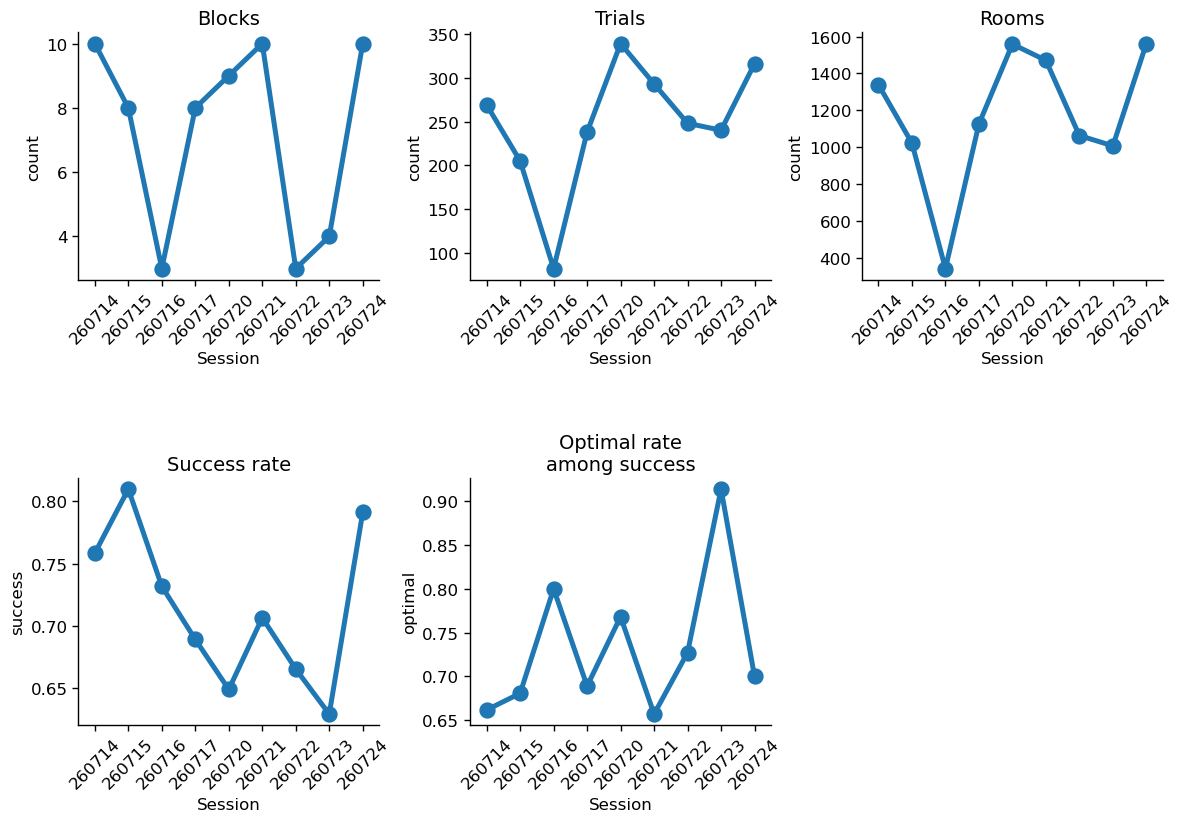

In [128]:
plt.close('all')
fig, axes = plt.subplots(2,3,figsize=(14,9),gridspec_kw={'wspace': 0.3, 'hspace': 0.8})

ax = axes[0,0]
df = nav.drop_duplicates(['Session', 'BlockNumber']).copy().groupby(['Session']).size().rename('count').reset_index()
sns.pointplot(data=df,x='Session',y='count',ax=ax)
ax.set_title('Blocks')
ax.tick_params(axis='x', labelrotation=45)

ax = axes[0,1]
df = nav_trial.groupby(['Session']).size().rename('count').reset_index()
sns.pointplot(data=df,x='Session',y='count',ax=ax)
ax.set_title('Trials')
ax.tick_params(axis='x', labelrotation=45)

ax = axes[0,2]
df = nav.groupby(['Session']).size().rename('count').reset_index()
sns.pointplot(data=df,x='Session',y='count',ax=ax)
ax.set_title('Rooms')
ax.tick_params(axis='x', labelrotation=45)

ax = axes[1,0]
df = nav_trial.groupby(['Session']).success.mean().reset_index()
sns.pointplot(data=df,x='Session',y='success',ax=ax)
ax.set_title('Success rate')
ax.tick_params(axis='x', labelrotation=45)

ax = axes[1,1]
df = nav_trial.query('success==1').groupby(['Session']).optimal.mean().reset_index()
sns.pointplot(data=df,x='Session',y='optimal',ax=ax)
ax.set_title('Optimal rate\namong success')
ax.tick_params(axis='x', labelrotation=45)

axes[1, 2].set_axis_off()

sns.despine()
plt.savefig(f'{FIGDIR} {date} basic quantifications.png')

#### Visualize the proportion of each distance in a block

In [92]:
group = nav_trial.groupby(['Session', 'BlockNumber', 'trial_in_block','graph_distance'])['graph_distance'].value_counts().reset_index()

counts = (
    group.query('trial_in_block < 41')
    .groupby(['trial_in_block', 'graph_distance'])
    .size()
    .unstack(fill_value=0)
)

prop = counts.div(counts.sum(axis=1), axis=0).rolling(3,center=True,min_periods=1).mean()

colors = sns.color_palette("plasma", n_colors=prop.shape[1])

Text(0, 0.5, 'Proportion')

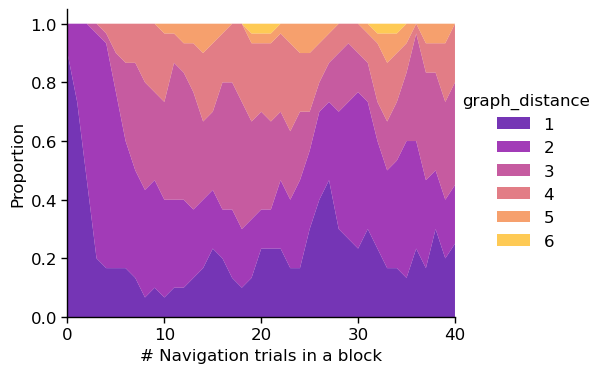

In [93]:
plt.close('all')
plt.figure(figsize=(5,4))
plt.stackplot(
    prop.index,
    prop.T,
    colors=colors,
    labels=prop.columns,
    alpha=0.8,
)
plt.legend(title='graph_distance',loc=[1,0.2])
plt.xlim(0,40)
sns.despine()
plt.xlabel('# Navigation trials in a block')
plt.ylabel('Proportion')
# plt.savefig(f'{FIGDIR} start room distance proportion.png')

<Axes: xlabel='graph_distance', ylabel='Proportion'>

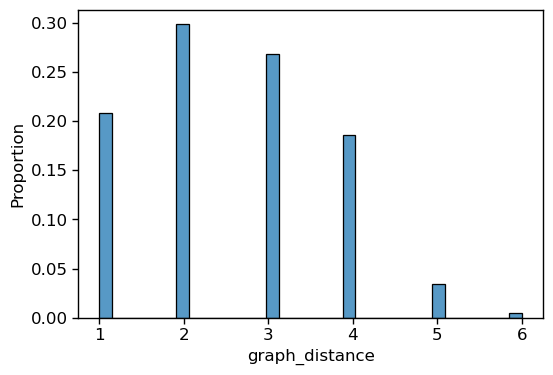

In [96]:
plt.close('all')
sns.histplot(data=nav_trial,x='graph_distance',stat='proportion')

### Trial level performance

#### Success rate as a function of distance and degree

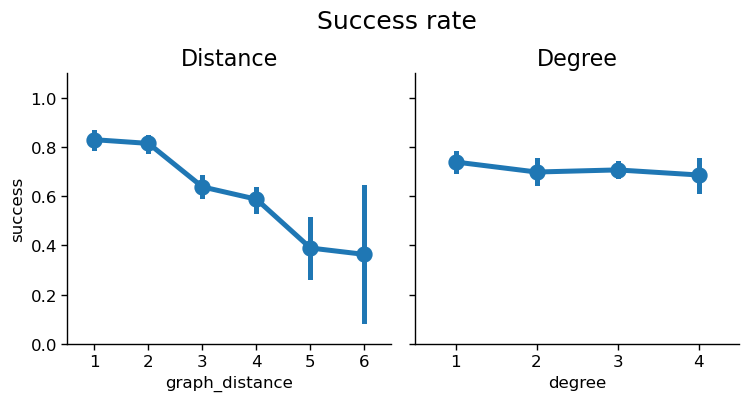

In [101]:
plt.close('all')
fig, axes = plt.subplots(1,2,figsize=(9,4),sharey=True)

ax=axes[0]
sns.pointplot(data=nav_trial,x='graph_distance',y='success',native_scale=True, ax=axes[0])
ax.set_ylim([0,1.1])
ax.set_xlim([0.5,6.5])
ax.set_title('Distance',fontsize=16)

ax=axes[1]
sns.pointplot(data=nav_trial,x='degree',y='success', native_scale=True, ax=axes[1])
ax.set_ylim([0,1.1])
ax.set_xlim([0.5,4.5])
ax.set_title('Degree',fontsize=16)
        
sns.despine()

fig.tight_layout(rect=[0.05, 0, 0.9, 0.95])
plt.suptitle('Success rate',fontsize=18, y=1)
plt.savefig(f'{FIGDIR} {date} Success rate.png')

#### Detour index as a function of distance and degree

Text(0.5, 1, 'Detour index')

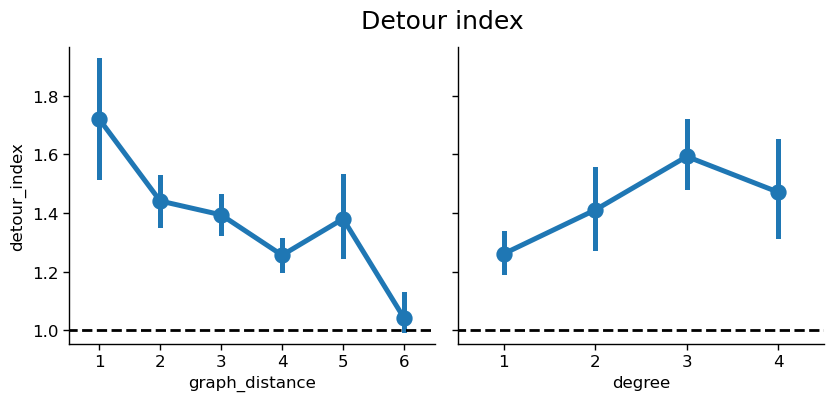

In [98]:
plt.close('all')
fig, axes = plt.subplots(1,2,figsize=(10,4),sharey=True)

ax=axes[0]
sns.pointplot(data=nav_trial[nav_trial.success==1],x='graph_distance',y='detour_index',native_scale=True, ax=axes[0])
ax.plot([-0.5,6.5],[1,1],'k--')
ax.set_xlim([0.5,6.5])

ax=axes[1]
sns.pointplot(data=nav_trial[nav_trial.success==1],x='degree',y='detour_index', native_scale=True, ax=axes[1])
ax.plot([-0.5,4.5],[1,1],'k--')
ax.set_xlim([0.5,4.5])
        
sns.despine()

fig.tight_layout(rect=[0.05, 0, 0.9, 0.95])
plt.suptitle('Detour index',fontsize=18, y=1)
# plt.savefig(f'{FIGDIR}{date} detour index.png')

#### Reaction time as a function of distance and degree

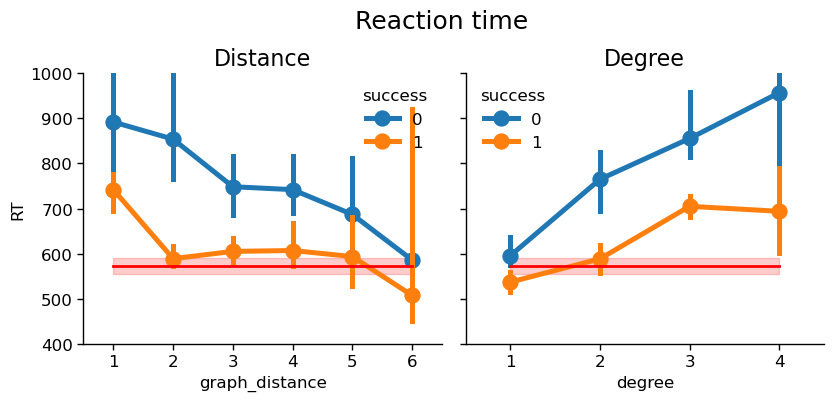

In [100]:
plt.close('all')
fig, axes = plt.subplots(1,2,figsize=(10,4),sharey=True)

ax=axes[0]
sns.pointplot(data=nav_trial,x='graph_distance',y='RT',hue='success',native_scale=True, ax=axes[0],estimator=np.median,errorbar=("ci", 95))
ax.plot([1,6],[flash_trial.RT.mean(),flash_trial.RT.mean()],color='r')
ax.fill_between([1,6],flash_trial.RT.mean()-flash_trial.RT.sem(),flash_trial.RT.mean()+flash_trial.RT.sem(),color='r',alpha=0.2)
ax.set_xlim([0.5,6.5])
ax.set_title('Distance',fontsize=16)
ax.set_ylim(400,1000)

ax=axes[1]
sns.pointplot(data=nav_trial,x='degree',y='RT',hue='success', native_scale=True, ax=axes[1],estimator=np.median,errorbar=("ci", 95))
ax.plot([1,4],[flash_trial.RT.mean(),flash_trial.RT.mean()],color='r')
ax.fill_between([1,4],flash_trial.RT.mean()-flash_trial.RT.sem(),flash_trial.RT.mean()+flash_trial.RT.sem(),color='r',alpha=0.2)
ax.set_xlim([0.5,4.5])
ax.set_title('Degree',fontsize=16)
        
sns.despine()

fig.tight_layout(rect=[0.05, 0, 0.9, 0.95])
plt.suptitle('Reaction time',fontsize=18, y=1)
plt.savefig(f'{FIGDIR} {date} reaction time.png')

In [103]:
model = smf.ols(formula='RT ~ success + EngagedTrialsInBlock + graph_distance + degree', data=nav_trial)
results = model.fit()
print(results.pvalues)
print(results.summary())

Intercept               1.048864e-32
success                 1.260723e-17
EngagedTrialsInBlock    3.403426e-07
graph_distance          1.357227e-04
degree                  3.780695e-11
dtype: float64
                            OLS Regression Results                            
Dep. Variable:                     RT   R-squared:                       0.072
Model:                            OLS   Adj. R-squared:                  0.070
Method:                 Least Squares   F-statistic:                     43.17
Date:                Sat, 25 Jul 2026   Prob (F-statistic):           6.20e-35
Time:                        16:16:30   Log-Likelihood:                -17769.
No. Observations:                2230   AIC:                         3.555e+04
Df Residuals:                    2225   BIC:                         3.558e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
          

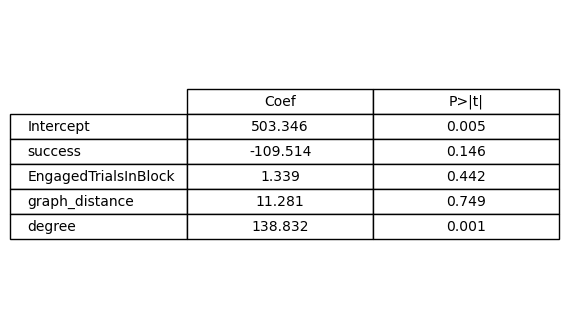

In [10]:
coef_table = pd.DataFrame({
    'Coef': results.params,
    'P>|t|': results.pvalues,
})

fig, ax = plt.subplots(figsize=(4, 2 + 0.4 * len(coef_table)))
ax.axis('off')

table = ax.table(
    cellText=coef_table.round(3).values,
    rowLabels=coef_table.index,
    colLabels=coef_table.columns,
    cellLoc='center',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)
# plt.savefig(f'{FIGDIR} {date} RT regression model')

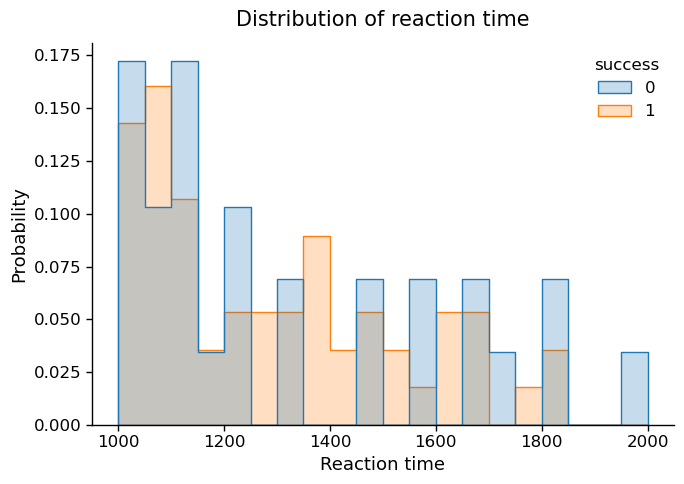

In [31]:
plt.close('all')

fig, ax = plt.subplots(figsize=(7,5))

sns.histplot(data=nav_trial,x='RT',hue='success',bins=np.linspace(1000,2000,21),
             stat='probability',common_norm=False,#multiple='dodge',
             ax=ax, element="step")

# sns.kdeplot(data=nav_trial,x='RT',hue='success',bw_adjust=0.1)

ax.set_xlabel('Reaction time', fontsize=13)
ax.set_ylabel('Probability', fontsize=13)
ax.set_title('Distribution of reaction time', fontsize=15, pad=12)

# ax.set_xlim([1000,5000])

sns.despine()
plt.tight_layout()
# plt.savefig('Distribution of reaction time')

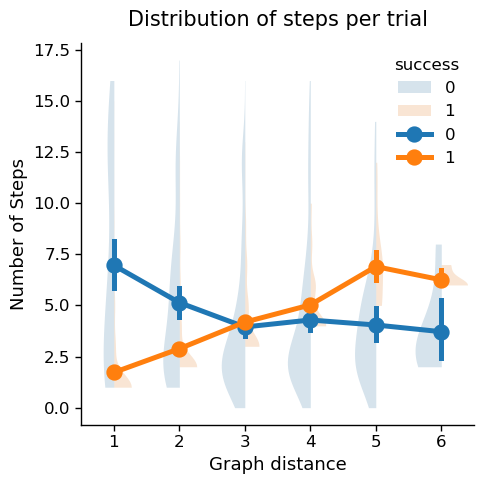

In [176]:
plt.close('all')

fig, ax = plt.subplots(figsize=(5,5))

sns.violinplot(data=nav_trial,y='minus_step',x='graph_distance',hue='success',split=True,alpha=0.2,inner=None,
    cut=0,
    linewidth=0,
    ax=ax
)

sns.pointplot(data=nav_trial,y='minus_step',x='graph_distance',hue='success',
    # dodge=True,
    # jitter=0.15,
    # alpha=0.25,
    # size=2.5,
    ax=ax
)

# Remove duplicate legends

ax.set_ylabel('Number of Steps', fontsize=13)
ax.set_xlabel('Graph distance', fontsize=13)
ax.set_title('Distribution of steps per trial', fontsize=15, pad=12)

sns.despine()
plt.tight_layout()
# plt.savefig('Distribution of steps per trial')

### Learning curve in a block

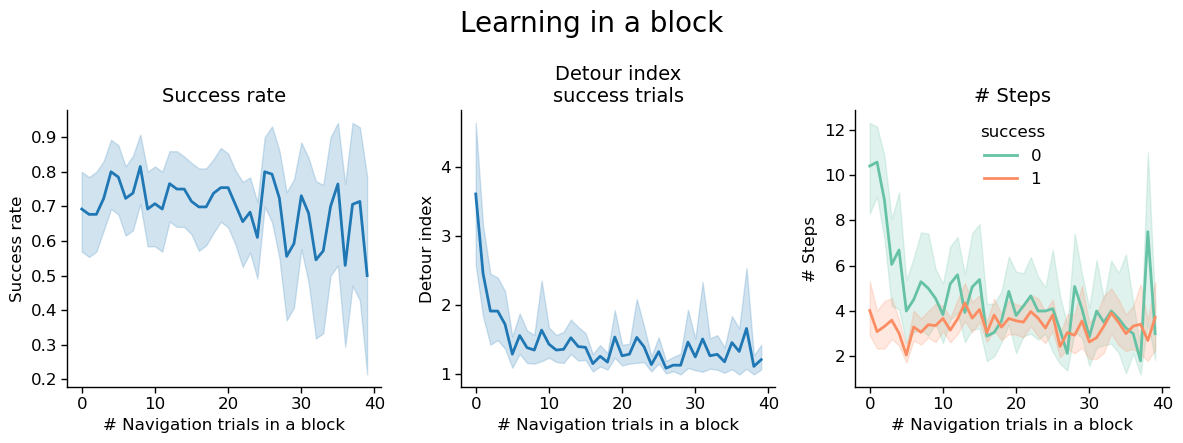

In [175]:
plt.close('all')
fig, axes = plt.subplots(1,3,figsize=(12,4.5))

sns.lineplot(data=nav_trial.query('trial_in_block < 40'),x='trial_in_block',y='success',ax=axes[0])
axes[0].set_xlabel('# Navigation trials in a block')
axes[0].set_ylabel('Success rate')
axes[0].set_title('Success rate')

sns.lineplot(data=nav_trial.query('(trial_in_block < 40) & (success==1)'),x='trial_in_block',y='detour_index',ax=axes[1])
axes[1].set_xlabel('# Navigation trials in a block')
axes[1].set_ylabel('Detour index')
axes[1].set_title('Detour index\nsuccess trials')

sns.lineplot(data=nav_trial.query('trial_in_block < 40'),x='trial_in_block',y='minus_step',ax=axes[2],hue='success',palette='Set2')
axes[2].set_xlabel('# Navigation trials in a block')
axes[2].set_ylabel('# Steps')
axes[2].set_title('# Steps')


sns.despine()
plt.suptitle('Learning in a block',fontsize=20)
plt.tight_layout(rect=[0, 0, 1, 1])  
plt.savefig(f'{FIGDIR} {date} block learning.png')

### Stickiness to the previous goal

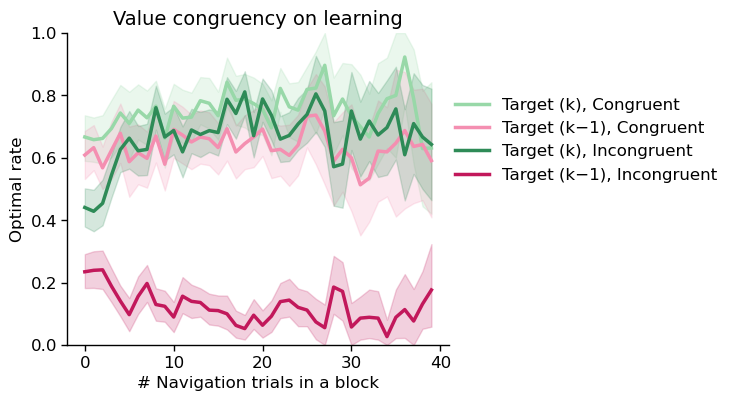

In [129]:
plt.close('all')

df = nav.query('trial_in_block < 40')

fig, ax = plt.subplots(figsize=(7.5, 4))

palette = {
    False:  ("#2E8B57", "#C2185B"),   # congruent: dark green, dark pink 
    True: ("#98D8A8", "#F48FB1"),   # incongruent:light green , light pink
}

for congruent in [True, False]:
    sub = df[df.congruent == congruent]

    sns.lineplot(
        data=sub,
        x='trial_in_block',
        y='optimal',
        color=palette[congruent][0],
        linewidth=2.5,
        label=f'Target (k), {"Congruent" if congruent else "Incongruent"}',
        ax=ax,
    )

    sns.lineplot(
        data=sub,
        x='trial_in_block',
        y='optimal_to_previous_target',
        color=palette[congruent][1],
        linewidth=2.5,
        label=f'Target (k−1), {"Congruent" if congruent else "Incongruent"}',
        ax=ax,
    )

ax.set(
    xlabel='# Navigation trials in a block',
    ylabel='Optimal rate',
    ylim=(0, 1)
)

ax.legend(
    frameon=False,
    title='',
    loc=(1,0.5)
)

sns.despine()
plt.tight_layout()
plt.title('Value congruency on learning')
plt.savefig(f'{FIGDIR} {date} Value congruency on learning, trial level.png')

Text(0.5, 1.0, 'Sticky to previous target')

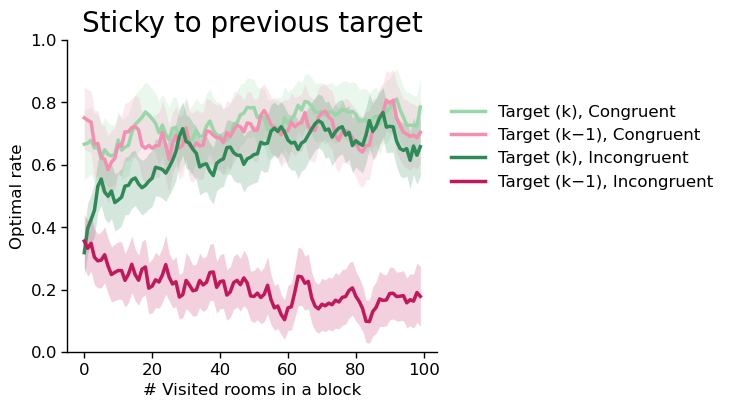

In [29]:
nav['room_in_block'] = nav.groupby(['Session','BlockNumber']).cumcount()

plt.close('all')

df = nav.query('room_in_block < 100')

fig, ax = plt.subplots(figsize=(7.5, 4))

palette = {
    False: ("#2E8B57", "#C2185B"),   # dark green, dark pink
    True:  ("#98D8A8", "#F48FB1"),   # light green, light pink
}

window = 5

for congruent in [True, False]:
    sub = df[df.congruent == congruent]

    for yvar, color, label in zip(
        ['optimal', 'optimal_to_previous_target'],
        palette[congruent],
        [
            f'Target (k), {"Congruent" if congruent else "Incongruent"}',
            f'Target (k−1), {"Congruent" if congruent else "Incongruent"}'
        ]
    ):

        summary = (
            sub.groupby('room_in_block')[yvar]
            .agg(mean='mean')
        )
        
        summary['sem'] = (
            sub.groupby('room_in_block')[yvar]
            .sem()
        )

        # Smooth mean and SEM
        summary['mean'] = (
            summary['mean']
            .rolling(window, center=True, min_periods=1)
            .mean()
        )

        summary['sem'] = (
            summary['sem']
            .rolling(window, center=True, min_periods=1)
            .mean()
        )

        ax.plot(
            summary.index,
            summary['mean'],
            color=color,
            lw=2.5,
            label=label,
        )

        ax.fill_between(
            summary.index,
            summary['mean'] - summary['sem'],
            summary['mean'] + summary['sem'],
            color=color,
            alpha=0.2,
            linewidth=0,
        )

ax.set(
    xlabel='# Visited rooms in a block',
    ylabel='Optimal rate',
    ylim=(0, 1),
)

ax.legend(
    frameon=False,
    title='',
    loc=(1.02, 0.5),
)

sns.despine()
plt.tight_layout()
plt.title('Sticky to previous target',fontsize=20)
plt.savefig(f'{FIGDIR} {date} Value congruency on learning, room level.png')

### Path dependence

In [11]:
def overlap_action(row,var1,var2):
    
    action = row[var1]
    prev_action = row[var2]

    if not isinstance(action, np.ndarray) or not isinstance(prev_action, np.ndarray):
        return np.nan

    mask = prev_action == 1
    selected = action[mask]

    if selected.size == 0:
        return np.nan
    if selected.size > 1:
        # more than one match — decide how you want to handle this
        # e.g. take the first, or flag it
        selected = selected[:1]

    val = selected[0]
    if np.isnan(val):
        return np.nan

    return val == 1

In [ ]:
# if multiple directions are correct, is there a bias towards recently visited direction?

In [45]:
def add_room_history_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy().reset_index(drop=True)
    df['_row_order'] = np.arange(len(df))
 
    # --- chronological trial order per Session (0, 1, 2, ... by first appearance) ---
    trial_first_seen = (
        df.groupby(['Session', 'Trial'], sort=False)['_row_order']
          .min()
          .reset_index()
          .sort_values(['Session', '_row_order'])
    )
    trial_first_seen['trial_index'] = trial_first_seen.groupby('Session').cumcount()
    trial_first_seen['prev_trial'] = trial_first_seen.groupby('Session')['Trial'].shift(1)
 
    df = df.merge(
        trial_first_seen[['Session', 'Trial', 'trial_index', 'prev_trial']],
        on=['Session', 'Trial'], how='left'
    )
 
    # --- outcome of the immediately preceding trial ---
    trial_outcome = (
        df.groupby(['Session', 'Trial'], sort=False)['TrialError']
          .first()
          .reset_index()
          .rename(columns={'Trial': 'prev_trial', 'TrialError': 'prev_trial_outcome'})
    )
    df = df.merge(trial_outcome, on=['Session', 'prev_trial'], how='left')
    df = df.drop(columns=['prev_trial'])
 
    # --- last encounter of current_room WITHIN each trial (one row per Session, Trial, room) ---
    last_encounter = (
        df.sort_values(['Session', 'Trial', 'step'])
          .drop_duplicates(subset=['Session', 'Trial', 'current_room'], keep='last')
          [['Session', 'trial_index', 'current_room', 'target_room','graph_distance','minus_step','success','action']]
          .rename(columns={
              'trial_index': 'last_encounter_trial_index',
              'target_room': 'last_encounter_target_room',
              'graph_distance': 'last_encounter_distance',
              'minus_step': 'last_encounter_minus_step',
              'success': 'last_encounter_success',
              'action': 'last_encounter_action'
          })
    )
 
    # --- asof-merge: closest PRIOR trial (any number of trials back) where this
    #     room was seen, grouped by Session & current_room. NOTE: merge_asof
    #     requires the `on` key sorted globally (not just within each by-group). ---
    left = df.sort_values('trial_index')
    right = last_encounter.sort_values('last_encounter_trial_index')
 
    merged = pd.merge_asof(
        left, right,
        left_on='trial_index', right_on='last_encounter_trial_index',
        by=['Session', 'current_room'],
        direction='backward',
        allow_exact_matches=False,   # must be STRICTLY earlier than the current trial
    )
 
    merged['trials_since_room_encounter'] = merged['trial_index'] - merged['last_encounter_trial_index']
 
    merged = merged.sort_values('_row_order').drop(
        columns=['_row_order', 'trial_index', 'last_encounter_trial_index']
    )
    return merged.reset_index(drop=True)

In [46]:
nav = add_room_history_features(nav)
nav.loc[nav.trial_in_block==1,'last_encounter_action']=np.nan
nav['repeat'] = nav.apply(lambda row: overlap_action(row,'action','last_encounter_action'), axis=1)
nav['is_last_encounter_correct_to_stay_the_same'] = nav.apply(lambda row: overlap_action(row,'correct_actions','last_encounter_action'), axis=1)

df = nav.dropna(subset=['repeat', 'is_last_encounter_correct_to_stay_the_same']).query('degree>1')
df['excess_repeat'] = df['repeat'].astype(int) - df['is_last_encounter_correct_to_stay_the_same'].astype(int)
df = df[df.target_room==df.last_encounter_target_room]

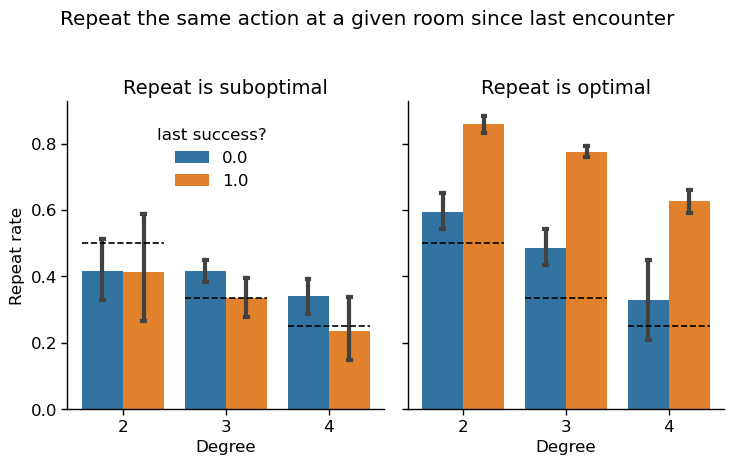

In [54]:
plt.close('all')
g = sns.catplot(
    data=df, kind='bar',
    x='degree', y='repeat',
    col='is_last_encounter_correct_to_stay_the_same',
    hue='last_encounter_success',
    errorbar='ci', capsize=0.05,
    height=4.5, aspect=0.6,
)

# overlay chance level (1/degree) per subplot
degree_order = sorted(df['degree'].unique())
for ax in g.axes.flat:
    for i, deg in enumerate(degree_order):
        ax.hlines(1/deg, i - 0.4, i + 0.4, colors='black', linestyles='--', linewidth=1.2)

g.set_axis_labels('Degree', 'Repeat rate')
g.legend.set_title('last success?')
sns.move_legend(g, loc='center left',bbox_to_anchor=(0.2, 0.7))

new_titles = ['Repeat is suboptimal', 'Repeat is optimal']
for ax, title in zip(g.axes.flat, new_titles):
    ax.set_title(title)
    
g.fig.suptitle('Repeat the same action at a given room since last encounter', y=1.03)
sns.despine()
plt.tight_layout()
plt.savefig(f'{FIGDIR} {date} path dependence')

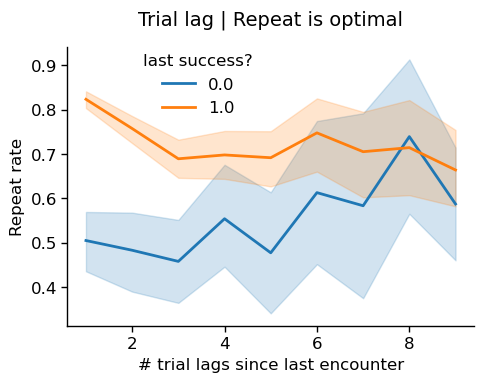

In [71]:
df.loc[df.trials_since_room_encounter>9,'trials_since_room_encounter']=9
plt.close('all')
plt.figure(figsize=(5,4))
sns.lineplot(data=df.query('is_last_encounter_correct_to_stay_the_same==True'),x='trials_since_room_encounter',y='repeat',hue='last_encounter_success')
plt.xlabel('# trial lags since last encounter')
plt.ylabel('Repeat rate')
plt.legend(title='last success?',loc=(0.17,0.73))
plt.title('Trial lag | Repeat is optimal',y=1.05)
sns.despine()
plt.tight_layout(rect=[0,0,1,1])
plt.savefig(f'{FIGDIR} {date} path dependence trial lag')

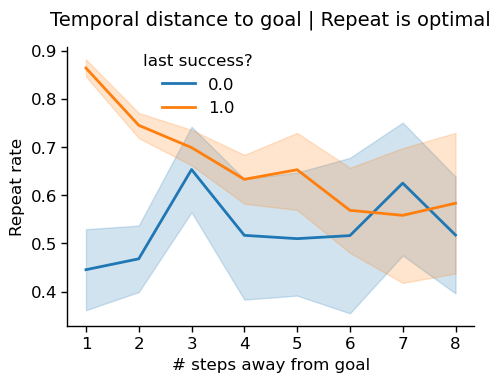

In [70]:
df.loc[df.last_encounter_minus_step>7,'last_encounter_minus_step']=8
plt.close('all')
plt.figure(figsize=(5,4))
sns.lineplot(data=df.query('is_last_encounter_correct_to_stay_the_same==True'),x='last_encounter_minus_step',y='repeat',hue='last_encounter_success')
plt.xlabel('# steps away from goal')
plt.ylabel('Repeat rate')
plt.legend(title='last success?',loc=(0.17,0.73))
plt.title('Temporal distance to goal | Repeat is optimal',y=1.05)
sns.despine()
plt.tight_layout(rect=[0,0,1,1])
plt.savefig(f'{FIGDIR} {date} path dependence temporal distance')

Text(0.5, 0, '# steps away from goal')

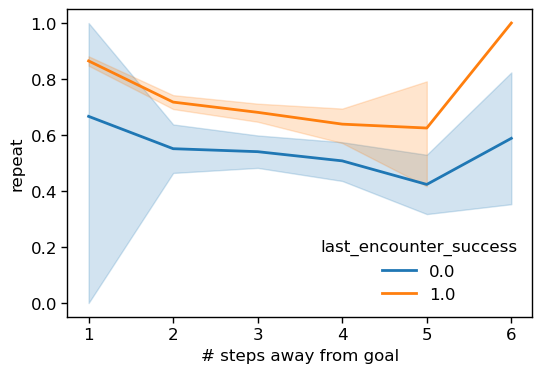

In [47]:
plt.close('all')
sns.lineplot(data=df.query('is_last_encounter_correct_to_stay_the_same==True'),x='last_encounter_distance',y='repeat',hue='last_encounter_success')
plt.xlabel('graph distance from goal')

### Inertia

In [ ]:
nav['prev_action'] = nav.groupby(['Session', 'BlockNumber', 'Trial'])['action'].shift(1)
nav['inertia'] = nav.apply(lambda row: overlap_action(row,'action','prev_action'), axis=1)
nav['is_prev_action_correct_to_stay_the_same'] = nav.apply(lambda row: overlap_action(row,'correct_actions','prev_action'), axis=1)

df = nav.dropna(subset=['action', 'prev_action','inertia','is_prev_action_correct_to_stay_the_same'])
df['excess_stay'] = df['inertia'] - df['is_prev_action_correct_to_stay_the_same'].astype(int)

In [81]:
nav['is_prev_action_correct_to_stay_the_same'].value_counts(normalize=True,dropna=False)

is_prev_action_correct_to_stay_the_same
NaN      0.607722
False    0.246139
True     0.146139
Name: proportion, dtype: float64

In [82]:
df.groupby(['degree','current_room']).count()

Session  BlockNumber  InitiatedTrialsInBlock  \
degree current_room                                                 
2      3                 398          398                     398   
3      2                 386          386                     386   
       6                 455          455                     455   
       7                 208          208                     208   
       8                 314          314                     314   
       9                 365          365                     365   
       11                324          324                     324   
       15                162          162                     162   
4      10                944          944                     944   

                     EngagedTrialsInBlock  correctTrialsInBlock  Trial  \
degree current_room                                                      
2      3                              398                   398    398   
3      2                              386                   386    386   
       6                              455                   455    455   
       7                              208                   208    208   
       8                              314                   314    314   
       9                              365                   365    365   
       11                             324                   324    324   
       15                             162                   162    162   
4      10                             944                   944    944   

                     instruct  target_room  start_room  TrialError  ...  \
degree current_room                                                 ...   
2      3                  398          398         398         398  ...   
3      2                  386          386         386         386  ...   
       6                  455          455         455         455  ...   
       7                  208          208         208         208  ...   
       8                  314          314         314         314  ...   
       9                  365          365         365         365  ...   
       11                 324          324         324         324  ...   
       15                 162          162         162         162  ...   
4      10                 944          944         944         944  ...   

                     correct_actions  closer_states_to_previous_target  \
degree current_room                                                      
2      3                         398                               335   
3      2                         386                               310   
       6                         455                               374   
       7                         208                               177   
       8                         314                               264   
       9                         365                               306   
       11                        324                               287   
       15                        162                               137   
4      10                        944                               757   

                     correct_actions_to_previous_target  \
degree current_room                                       
2      3                                            398   
3      2                                            386   
       6                                            455   
       7                                            208   
       8                                            314   
       9                                            365   
       11                                           324   
       15                                           162   
4      10                                           944   

                     optimal_to_previous_target  intersect  congruent  \
degree current_room                                                     
2      3 

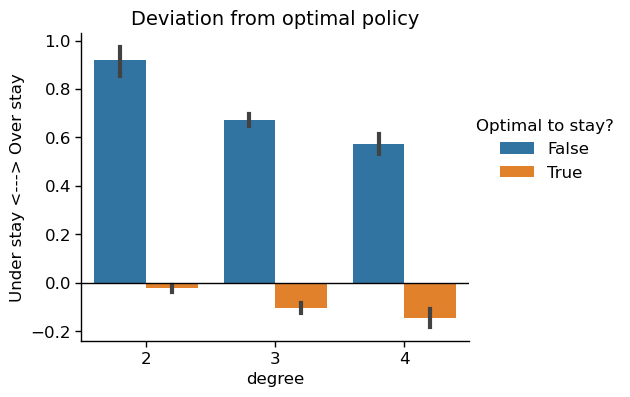

In [125]:
plt.close('all')
plt.figure(figsize=(5,4))
sns.barplot(data=df,y='excess_stay',x='degree',hue='is_prev_action_correct_to_stay_the_same') # this is observation, not expectation
plt.ylabel('Under stay <---> Over stay')
plt.title('Deviation from optimal policy')
plt.legend(title='Optimal to stay?',loc=(1,0.5))
sns.despine()
plt.axhline(0, color='black', linewidth=1)

plt.savefig(f'{FIGDIR} {date} Inertia')

### Motor Bias

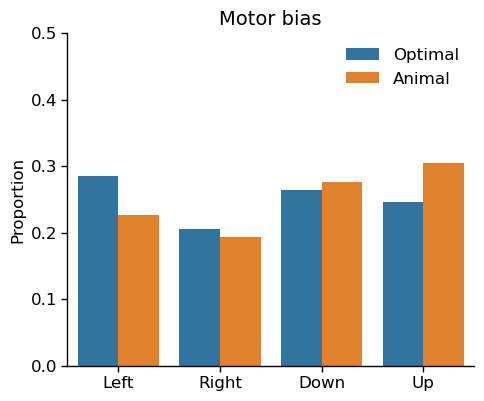

In [108]:
# Sum over all trials
correct = np.nansum(np.vstack(nav.correct_actions), axis=0)
chosen = np.nansum(np.vstack(nav.dropna(subset='action').action), axis=0)

# Normalize to proportions
correct = correct / correct.sum()
chosen = chosen / chosen.sum()

# Create dataframe
df = pd.DataFrame({
    'Action': ['Left', 'Right', 'Down', 'Up'] * 2,
    'Proportion': np.r_[correct, chosen],
    'Group': ['Optimal'] * 4 + ['Animal'] * 4
})

plt.close('all')
plt.figure(figsize=(5,4))

sns.barplot(
    data=df,
    x='Action',
    y='Proportion',
    hue='Group')

plt.ylabel('Proportion')
plt.xlabel('')
plt.ylim(0, 0.5)
sns.despine()
plt.tight_layout()
plt.title('Motor bias')
plt.legend(title='')
plt.savefig(f'{FIGDIR} {date} motor bias.png')

### Target subset

In [12]:
from plot_grid import plot_target_coverage, plot_target_subset

In [13]:
# divide target into two subsets
set1 = np.array([7,10,2,12,16,1,9,15])
set2 = np.array([6,11,5,13,4,3,14,8])

# unweighted graph (BFS-based)
lengths = dict(nx.all_pairs_shortest_path_length(G))

# weighted graph — use this instead if your edges have a 'weight' attr
# lengths = dict(nx.all_pairs_dijkstra_path_length(G, weight='weight'))

df = pd.DataFrame(
    [{'source': s+1, 'target': t+1, 'distance': d}
     for s, targets in lengths.items()
     for t, d in targets.items()]
)
df = df[df.distance>0]
df['set'] = np.isin(df.target,set1)

target_df = df[df.distance < 5].copy()
target_df['weight'] = (
    0.25 / target_df.groupby(['target', 'distance'])['distance'].transform('size')
)

In [14]:
# mean distance of each subset of targets
df.groupby('set').mean()

,source,target,distance
set,,,
False,8.533333,8.0,3.133333
True,8.466667,9.0,3.133333


In [15]:
target_distance = df.groupby('target')['distance'].mean().reset_index().sort_values(by='distance')

In [16]:
np.sort(set1)

array([ 1,  2,  7,  9, 10, 12, 15, 16])

In [17]:
np.sort(set2)

array([ 3,  4,  5,  6,  8, 11, 13, 14])

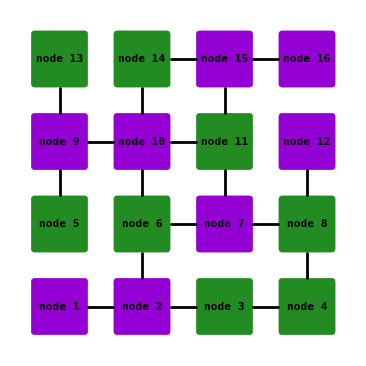

In [23]:
ax = plot_target_subset(G,set1-1,set2-1)
plt.savefig(f'{FIGDIR} target subset')

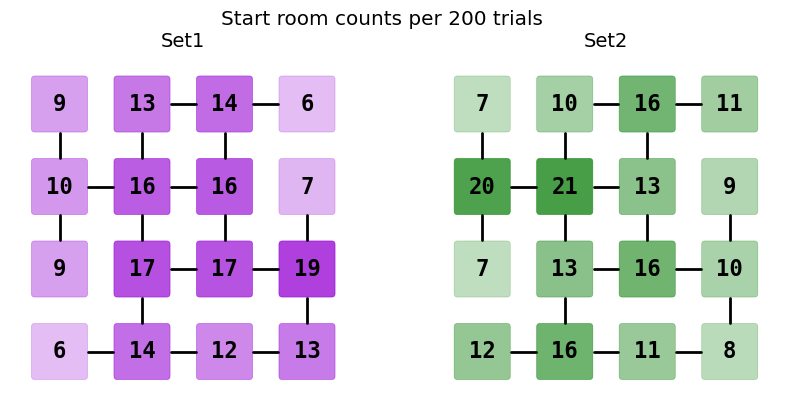

In [27]:
fig, axes = plt.subplots(1,2,figsize=(10, 4.5))

set1_freq = target_df.query('set')
set1_freq['count'] = set1_freq.groupby('source')['weight'].transform('sum')*25
set1_freq = set1_freq.drop_duplicates('source')

ax=axes[0]
plot_target_coverage(G,0.04,ax=ax)
ax.set_title('Set1')


set1_freq = target_df.query('~set')
set1_freq['count'] = set1_freq.groupby('source')['weight'].transform('sum')*25
set1_freq = set1_freq.drop_duplicates('source')

ax=axes[1]
plot_target_coverage(G,0.04,ax=ax,near_color='forestgreen')
ax.set_title('Set2')

plt.suptitle('Start room counts per 200 trials')
plt.savefig(f'{FIGDIR}Start room counts per 200 trials')

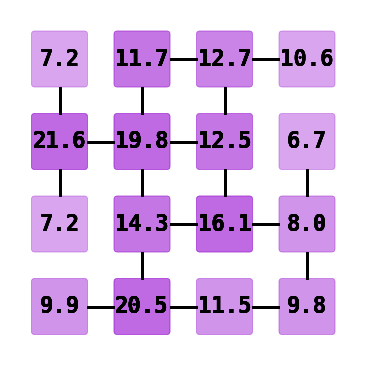

In [203]:
set1_freq = target_df.query('~set')
set1_freq['count'] = set1_freq.groupby('source')['weight'].transform('sum')*25
set1_freq = set1_freq.drop_duplicates('source')

fig, ax = plt.subplots(figsize=(4.5, 4.5))
for target in set2:
    plot_target_coverage(G,target-1,0.1,ax=ax)

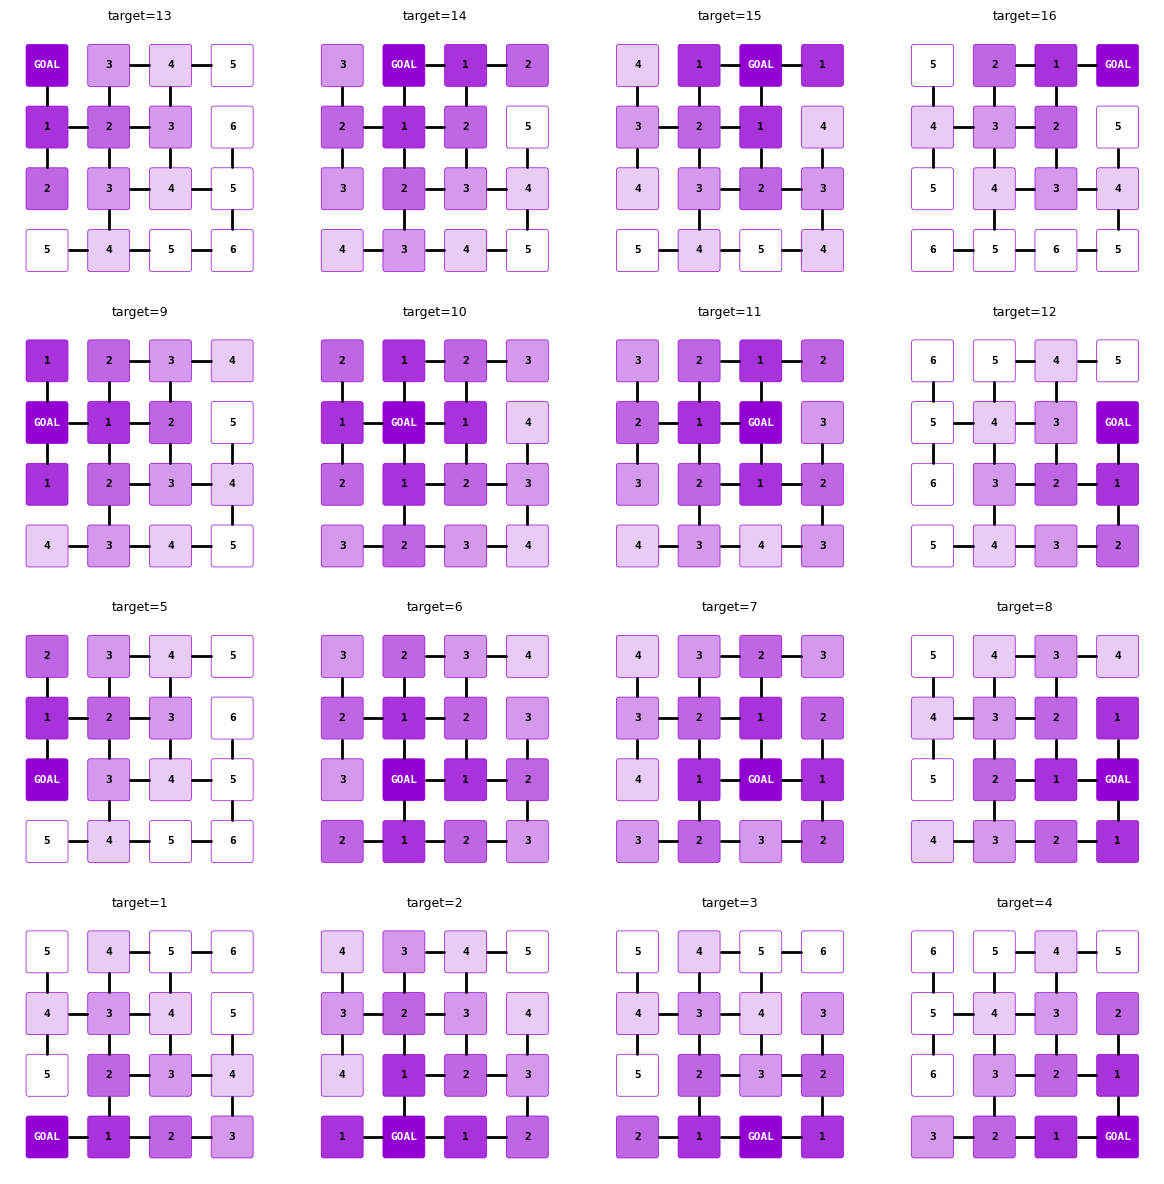

In [47]:
fig = plot_all_targets(G, size=4, boundary_distance=4, ncols=4, panel_size=3.0)
plt.savefig(f'{FIGDIR}Distance grid plot for each target')

### Room level performance

#### Room accuracy

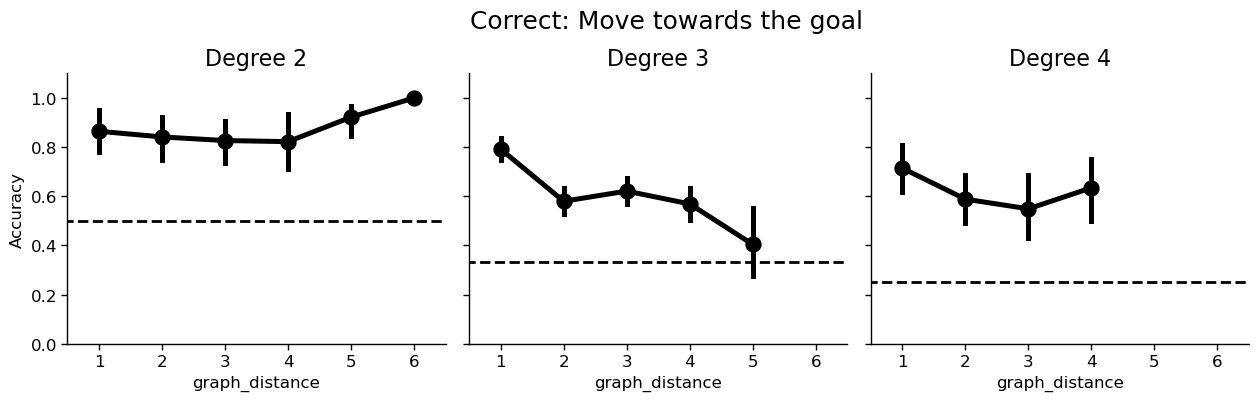

In [57]:
plt.close('all')
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for dd in range(3):
    ax = axes[dd]
    sns.pointplot(data=nav[(nav.graph_distance>0) & (nav.degree==dd+2)],x='graph_distance',y='room_accuracy',native_scale=True,ax=ax,color='k')
    ax.plot([-0.5,6.5],[1/(dd+2),1/(dd+2)],'k--')
    ax.set_ylim([0,1.1])
    ax.set_xlim([0.5,6.5])
    ax.set_title(f'Degree {dd+2}',fontsize=16)

    if dd==0:
        ax.set_ylabel('Accuracy')
        
sns.despine()
fig.tight_layout(rect=[0.05, 0, 0.9, 0.95])
plt.suptitle('Correct: Move towards the goal',fontsize=18, y=1)
plt.savefig(f'{FIGDIR} {date} Room accuracy.png')

In [ ]:
# dwell long, but no pauses -> course correction

nav['room_cumcount'] = nav.groupby('current').cumcount()

plt.close('all')
sns.pointplot(data=nav[nav.target==7],x='current',y='dwell')

plt.close('all')
sns.lineplot(data=nav[nav.current==7].rolling(9,center=True).mean(),x='room_cumcount',y='dwell')
# sns.lineplot(data=df0603[df0603.current==15].rolling(10,center=True).mean(),x='room_cumcount',y='duration')
plt.ylim(500,3000)

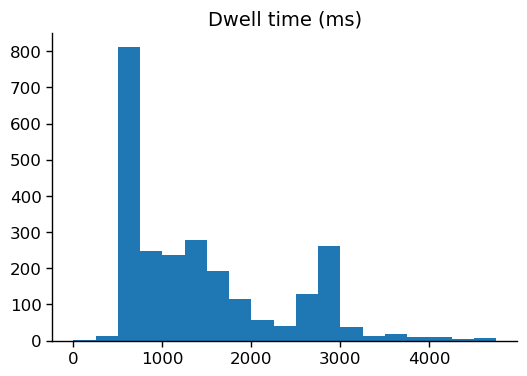

In [97]:
plt.close('all')
plt.figure(figsize=(6,4))
plt.hist(nav.dwell.values,bins=np.arange(0,5000,250))
plt.title('Dwell time (ms)')
sns.despine()
# plt.savefig('Dwell time')

Text(0.5, 1.0, 'Dwell time & Distance')

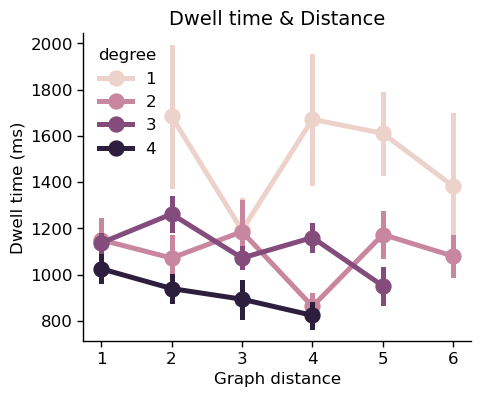

In [62]:
plt.close('all')
plt.figure(figsize=(5, 4))
df = nav[(nav.step>1)&(nav.minus_step>0)&(nav.graph_distance>0)]  
ax = sns.pointplot(data=df,x='graph_distance',y='dwell',native_scale=True,hue='degree',errorbar=('se', 1))
# handles, labels = ax.get_legend_handles_labels()
# ax.legend(handles, {'Fail','Success'}, frameon=False, title='')
# sns.regplot(data=df,x='graph_distance',y='duration',scatter=False,color='lightblue')

# mod = sm.OLS(df.duration.values,sm.add_constant(df.graph_distance.values))
# res = mod.fit()

# plt.text(
#     0.05, 0.95,
#     f'y = {res.params[1]:.2f}x + {res.params[0]:.2f}\nR2={res.rsquared:.2e}\npval={res.pvalues[1]:.2e}',
#     transform=plt.gca().transAxes,
#     va='top'
# )

sns.despine()
plt.ylabel('Dwell time (ms)')
plt.xlabel('Graph distance')
plt.title('Dwell time & Distance')
# plt.savefig('Dwell time and distance and degree')

Text(0.5, 1.0, 'Dwell time & Degree')

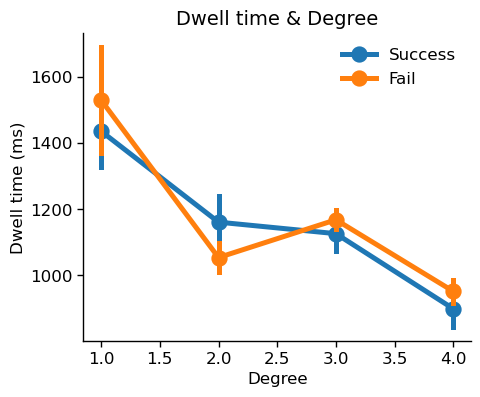

In [63]:
plt.close('all')
plt.figure(figsize=(5, 4))
df = nav[(nav.step>1)&(nav.minus_step>0)&(nav.graph_distance>0)]  # not the start, not the last room
ax = sns.pointplot(data=df,x='degree',y='dwell',native_scale=True,hue='success',errorbar=('se', 1))

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, {'Fail','Success'}, frameon=False, title='')

# sns.regplot(data=df,x='graph_distance',y='duration',scatter=False,color='lightblue')

# mod = sm.OLS(df.duration.values,sm.add_constant(df.graph_distance.values))
# res = mod.fit()

# plt.text(
#     0.05, 0.95,
#     f'y = {res.params[1]:.2f}x + {res.params[0]:.2f}\nR2={res.rsquared:.2e}\npval={res.pvalues[1]:.2e}',
#     transform=plt.gca().transAxes,
#     va='top'
# )

sns.despine()
plt.ylabel('Dwell time (ms)')
plt.xlabel('Degree')
plt.title('Dwell time & Degree')
# plt.savefig('Dwell time and degree')

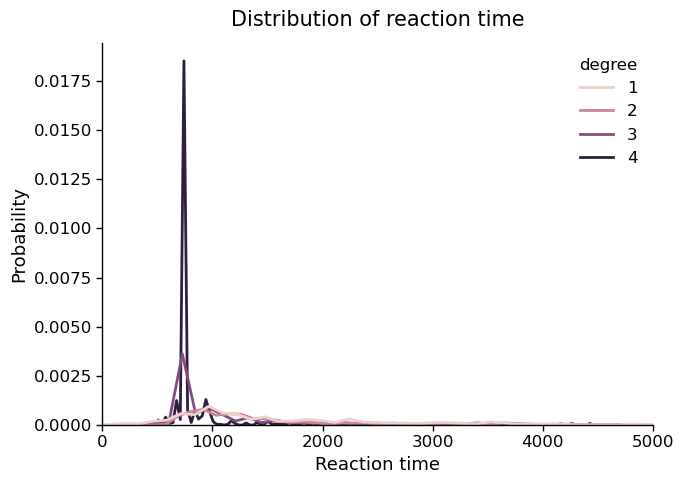

In [122]:
plt.close('all')
fig, ax = plt.subplots(figsize=(7,5))

df = nav[(nav.step>1)&(nav.minus_step>0)&(nav.graph_distance>0)]  #

sns.histplot(data=df,x='duration',hue='degree',bins=np.arange(0,3000,100),
             stat='probability',common_norm=False,#multiple='dodge',
             ax=ax, element="poly")

# sns.kdeplot(data=df,x='duration',hue='degree',bw_adjust=0.05,common_norm=False)

ax.set_xlabel('Reaction time', fontsize=13)
ax.set_ylabel('Probability', fontsize=13)
ax.set_title('Distribution of reaction time', fontsize=15, pad=12)

ax.set_xlim([0,5000])
# ax.set_yscale('log')

sns.despine()
plt.tight_layout()
# plt.savefig('Distribution of reaction time')

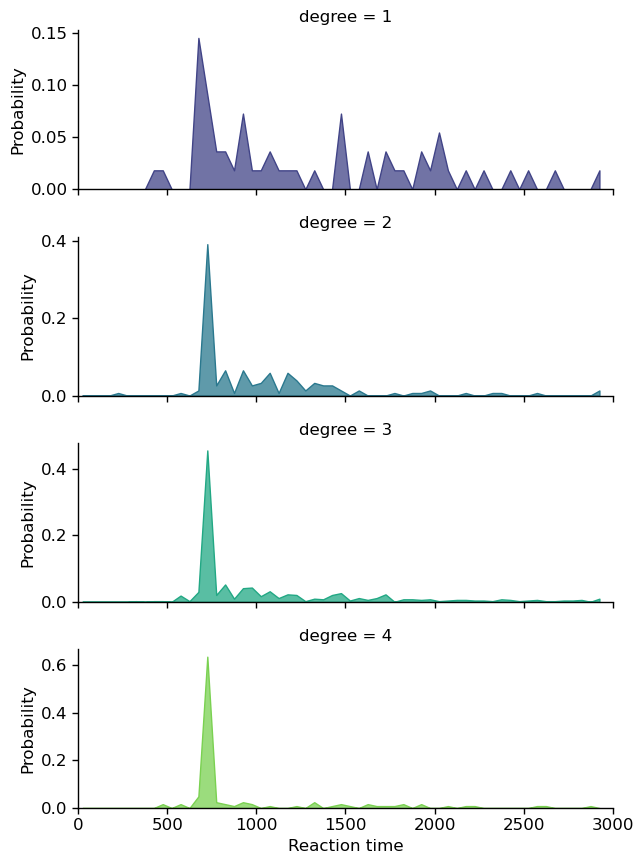

In [57]:
degrees = sorted(df.degree.unique())
palette = sns.color_palette("viridis", len(degrees))

g = sns.FacetGrid(df,row='degree',hue='degree',
    palette=palette,height=2.2,aspect=3,sharex=True,sharey=False)

g.map_dataframe(
    sns.histplot,
    x='dwell',bins=np.arange(0,3000,50),
             stat='probability',common_norm=False,#multiple='dodge',
             element="poly"
)

g.set_axis_labels('Reaction time', 'Probability')
g.set(xlim=(0, 3000))

sns.despine()
plt.tight_layout()

# Model fitting

#### Create gym environment

#### Model 1: Random policy

In [400]:
def model1(nrep = 100, cutoff=30):
    
    steps = np.zeros((16,16,nrep))
    success = np.zeros((16,16,nrep))
    
    for target in range(16):
    
        env = NewWorldEnv()
        
        for start in range(16):
            
            if target!=start:
                
                for n in range(nrep):
                
                    obs, info = env.reset(target,start)
                    total_reward = 0
                    
                    while True:
                        
                        valid_actions, _ = np.where(np.squeeze(env.T[obs,:,:]))
                        # choose a valid action randomly
                        action  = np.random.choice(valid_actions)     
                        obs, reward, terminated, truncated, info = env.step(action, cutoff)
                        total_reward += reward
                    
                        if terminated:
                            success[target,start,n] = 1
                            # print(f"Done! Total reward: {total_reward:.1f}")
                            break
                            
                        if truncated:
                            # print("Failed!")
                            break
                
                    steps[target,start,n] = info['steps']
            
    # print(f"steps taken: {info['steps']}")
    
    dist_matrix = shortest_path(env.T.sum(axis=1)>0, directed=False, unweighted=True)
    all_dis = np.tile(dist_matrix[:,:,None],(1,1,nrep))
    
    sim = pd.DataFrame({"target": np.ravel(np.tile(np.arange(16)[:,None,None],(1,16,nrep))), 
                       "start": np.ravel(np.tile(np.arange(16)[None,:,None],(16,1,nrep))),
                       "graph_distance": np.ravel(all_dis), 
                       "steps": np.ravel(steps),
                       "success": np.ravel(success)})
    sim = sim[sim.graph_distance>0]
    sim['detour_index'] = sim.steps/sim.graph_distance
    
    return sim

model1_df = model1()

In [401]:
def model1(env, obs, info, cutoff=30):
                        
    valid_actions, _ = np.where(np.squeeze(env.T[obs,:,:]))
    action  = np.random.choice(valid_actions)     
    obs, reward, terminated, truncated, info = env.step(action, cutoff)
    
    return obs, reward, terminated, truncated, info


#### Model 2: Choose one direction, hit wall, then change direction

In [183]:
def model2(env, obs, info, action, cutoff=30):
                
    # see what are the available actions in the current room
    valid_actions, _ = np.where(np.squeeze(env.T[obs,:,:]))
    
    if len(info) == 0:
        # choose an action to go at the start of a trial
        action  = np.random.choice(valid_actions) 
    else:
        # if previous action is valid, continue; if not, choose one randomly from valid actions
        if ~np.isin(action,valid_actions):
            action  = np.random.choice(valid_actions)     

    obs, reward, terminated, truncated, info = env.step(action, cutoff)

    return obs, reward, terminated, truncated, info, action

#### Model 3: Action learning, regardless of state
when there is learning component, transition between targets matter, some target transitons will be eaiser, some will be harder

In [184]:
def model3(Qa, env, obs, cutoff = 30, alpha=0.2):

    # choose action with softmax policy based on the accumulated action value
    valid_actions, _ = np.where(np.squeeze(env.T[obs,:,:]))
    policy = softmax(Qa[valid_actions])
    action = np.random.choice(valid_actions, p=policy)

    obs, reward, terminated, truncated, info = env.step(action, cutoff)
    Qa[action] = Qa[action] + alpha*(reward-Qa[action])

    return Qa, obs, reward, terminated, truncated, info

#### Model 4: Q learning

In [185]:
def model4(Qsa, env, obs, cutoff = 30, alpha = 0.1, gamma = 0.9):
    
    # choose action with softmax policy based on the accumulated action value
    s = obs
    valid_actions, _ = np.where(np.squeeze(env.T[obs,:,:]))
    policy = softmax(Qsa[s,valid_actions])
    action = np.random.choice(valid_actions, p=policy)
    obs, reward, terminated, truncated, info = env.step(action, cutoff)
    
    # update q value
    if terminated:
        Qsa[s,action] = Qsa[s,action] + alpha * (reward - Qsa[s,action])
    else:
        s_prime = list(G.neighbors(s))  # q learning is off-policy - find all possible successors
        Qsa[s,action] = Qsa[s,action] + alpha * (reward + gamma * np.nanmax(Qsa[s_prime]) - Qsa[s,action])

    return Qsa, obs, reward, terminated, truncated, info

#### Model 5: Successor representation

In [404]:
model1_trial, model1_room = simulate_a_session(nav_trial,model1,nrep=20)

KeyboardInterrupt: 

In [405]:
model1_trial30, model1_room30 = simulate_a_session(nav_trial,model1,nrep=20)

In [ ]:
model2_trial, model2_room = simulate_a_session(nav_trial,model2,nrep=20)
model3_trial, model3_room = simulate_a_session(nav_trial,model3,nrep=20)
model4_trial, model4_room = simulate_a_session(nav_trial,model4,nrep=20)

In [186]:
model2_trial30, model2_room30 = simulate_a_session(nav_trial,model2,nrep=20)
model3_trial30, model3_room30 = simulate_a_session(nav_trial,model3,nrep=20)
model4_trial30, model4_room30 = simulate_a_session(nav_trial,model4,nrep=20)

# Data & Model comparison

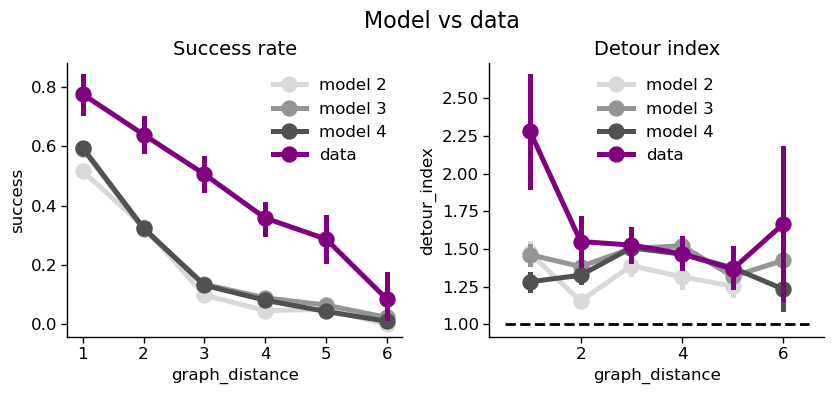

In [168]:
plt.close('all')
colors = sns.color_palette('Greys',3)
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
sns.pointplot(data = model2_trial, x = 'graph_distance', y = 'success', ax = ax[0], native_scale=True, color=colors[0], label='model 2')
sns.pointplot(data = model3_trial, x = 'graph_distance', y = 'success', ax = ax[0], native_scale=True, color=colors[1], label='model 3')
sns.pointplot(data = model4_trial, x = 'graph_distance', y = 'success', ax = ax[0], native_scale=True, color=colors[2], label='model 4')
sns.pointplot(data = nav_trial, x = 'graph_distance', y = 'success', ax = ax[0], native_scale=True, color='purple', label='data')
ax[0].set_title('Success rate', fontsize=14)

sns.pointplot(data = model2_trial[model2_trial.success==1], x = 'graph_distance', y = 'detour_index', ax = ax[1], native_scale=True, color=colors[0], label='model 2')
sns.pointplot(data = model3_trial[model3_trial.success==1], x = 'graph_distance', y = 'detour_index', ax = ax[1], native_scale=True, color=colors[1], label='model 3')
sns.pointplot(data = model4_trial[model4_trial.success==1], x = 'graph_distance', y = 'detour_index', ax = ax[1], native_scale=True, color=colors[2], label='model 4')
sns.pointplot(data = nav_trial[nav_trial.success==1], x = 'graph_distance', y = 'detour_index', ax = ax[1], native_scale=True, color='purple', label='data')
ax[1].set_title('Detour index', fontsize=14)
ax[1].plot([0.5,6.5],[1,1],'k--')

sns.despine()

fig.tight_layout(rect=[0.05, 0, 0.9, 0.95])
fig.suptitle('Model vs data', fontsize=16)
# plt.savefig('Model vs data cutoff trial specific.png')

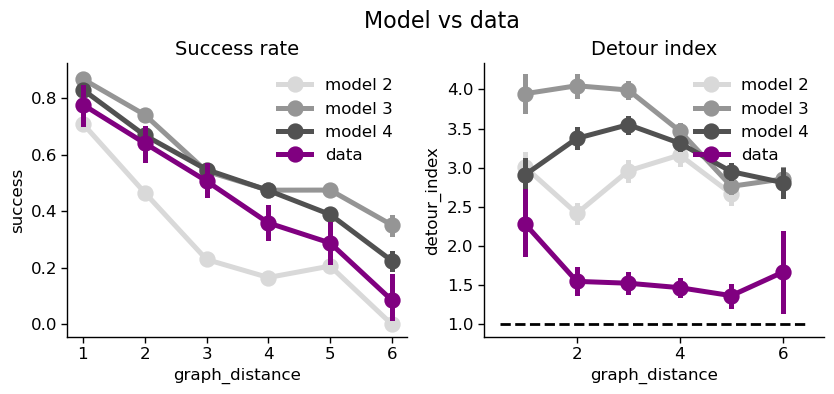

In [191]:
plt.close('all')
colors = sns.color_palette('Greys',3)
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
sns.pointplot(data = model2_trial30, x = 'graph_distance', y = 'success', ax = ax[0], native_scale=True, color=colors[0], label='model 2')
sns.pointplot(data = model3_trial30, x = 'graph_distance', y = 'success', ax = ax[0], native_scale=True, color=colors[1], label='model 3')
sns.pointplot(data = model4_trial30, x = 'graph_distance', y = 'success', ax = ax[0], native_scale=True, color=colors[2], label='model 4')
sns.pointplot(data = nav_trial, x = 'graph_distance', y = 'success', ax = ax[0], native_scale=True, color='purple', label='data')
ax[0].set_title('Success rate', fontsize=14)

sns.pointplot(data = model2_trial30[model2_trial30.success==1], x = 'graph_distance', y = 'detour_index', ax = ax[1], native_scale=True, color=colors[0], label='model 2')
sns.pointplot(data = model3_trial30[model3_trial30.success==1], x = 'graph_distance', y = 'detour_index', ax = ax[1], native_scale=True, color=colors[1], label='model 3')
sns.pointplot(data = model4_trial30[model4_trial30.success==1], x = 'graph_distance', y = 'detour_index', ax = ax[1], native_scale=True, color=colors[2], label='model 4')
sns.pointplot(data = nav_trial[nav_trial.success==1], x = 'graph_distance', y = 'detour_index', ax = ax[1], native_scale=True, color='purple', label='data')
ax[1].set_title('Detour index', fontsize=14)
ax[1].plot([0.5,6.5],[1,1],'k--')

sns.despine()

fig.tight_layout(rect=[0.05, 0, 0.9, 0.95])
fig.suptitle('Model vs data', fontsize=16)
plt.savefig('Model vs data cutoff 30.png')

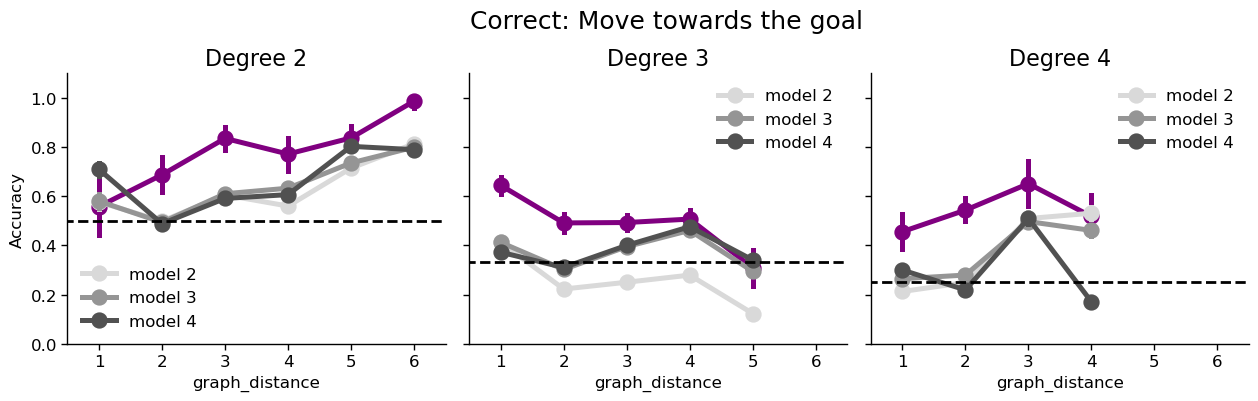

In [205]:
plt.close('all')
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
colors = sns.color_palette('Greys',3)

for dd in range(3):
    ax = axes[dd]
    sns.pointplot(data=nav[(nav.graph_distance>0) & (nav.degree==dd+2)],x='graph_distance',y='room_accuracy',native_scale=True,ax=ax,color='purple')
    # sns.pointplot(data = model2_room30[(model2_room30.graph_distance>0) & (model2_room30.degree==dd+2)].reset_index(), x = 'graph_distance', y = 'room_accuracy', ax = ax, native_scale=True, color=colors[0], label='model 2')
    # sns.pointplot(data = model3_room30[(model3_room30.graph_distance>0) & (model3_room30.degree==dd+2)].reset_index(), x = 'graph_distance', y = 'room_accuracy', ax = ax, native_scale=True, color=colors[1], label='model 3')
    # sns.pointplot(data = model4_room30[(model4_room30.graph_distance>0) & (model4_room30.degree==dd+2)].reset_index(), x = 'graph_distance', y = 'room_accuracy', ax = ax, native_scale=True, color=colors[2], label='model 4')
    sns.pointplot(data = model2_room[(model2_room.graph_distance>0) & (model2_room.degree==dd+2)].reset_index(), x = 'graph_distance', y = 'room_accuracy', ax = ax, native_scale=True, color=colors[0], label='model 2')
    sns.pointplot(data = model3_room[(model3_room.graph_distance>0) & (model3_room.degree==dd+2)].reset_index(), x = 'graph_distance', y = 'room_accuracy', ax = ax, native_scale=True, color=colors[1], label='model 3')
    sns.pointplot(data = model4_room[(model4_room.graph_distance>0) & (model4_room.degree==dd+2)].reset_index(), x = 'graph_distance', y = 'room_accuracy', ax = ax, native_scale=True, color=colors[2], label='model 4')
    ax.plot([-0.5,6.5],[1/(dd+2),1/(dd+2)],'k--')
    ax.set_ylim([0,1.1])
    ax.set_xlim([0.5,6.5])
    ax.set_title(f'Degree {dd+2}',fontsize=16)

    if dd==0:
        ax.set_ylabel('Accuracy')
        
sns.despine()
fig.tight_layout(rect=[0.05, 0, 0.9, 0.95])
plt.suptitle('Correct: Move towards the goal',fontsize=18, y=1)
plt.savefig('Model vs Data Room accuracy.png')

In [221]:
model2_trial['correctTrialsInBlock'] = model2_trial['success'].groupby([model2_trial['Session'],model2_trial['BlockNumber'],model2_trial['nrep']]).cumsum()
model3_trial['correctTrialsInBlock'] = model3_trial['success'].groupby([model3_trial['Session'],model3_trial['BlockNumber'],model3_trial['nrep']]).cumsum()
model4_trial['correctTrialsInBlock'] = model4_trial['success'].groupby([model4_trial['Session'],model4_trial['BlockNumber'],model4_trial['nrep']]).cumsum()

In [229]:
model2_trial30['correctTrialsInBlock'] = model2_trial30['success'].groupby([model2_trial30['Session'],model2_trial30['BlockNumber'],model2_trial30['nrep']]).cumsum()
model3_trial30['correctTrialsInBlock'] = model3_trial30['success'].groupby([model3_trial30['Session'],model3_trial30['BlockNumber'],model3_trial30['nrep']]).cumsum()
model4_trial30['correctTrialsInBlock'] = model4_trial30['success'].groupby([model4_trial30['Session'],model4_trial30['BlockNumber'],model4_trial30['nrep']]).cumsum()

In [445]:
nav_trial.query('EngagedTrialsInBlock<10').success.mean()

np.float64(0.5104895104895105)

Text(0.5, 1, 'Learning in a block')

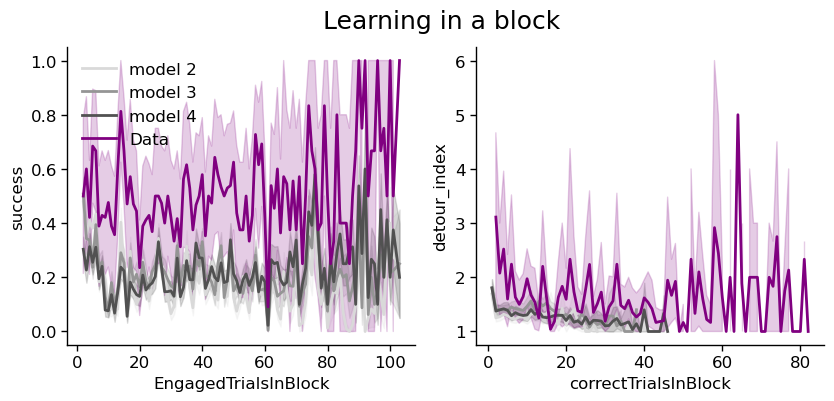

In [446]:
plt.close('all')
fig, axes = plt.subplots(1,2,figsize=(10,4))
colors = sns.color_palette('Greys',3)

sns.lineplot(data=model2_trial,x='EngagedTrialsInBlock',y='success', ax=axes[0],label='model 2',color=colors[0])
sns.lineplot(data=model2_trial.query('success'),x='correctTrialsInBlock',y='detour_index', ax=axes[1],color=colors[0])    

sns.lineplot(data=model3_trial,x='EngagedTrialsInBlock',y='success', ax=axes[0],label='model 3',color=colors[1])
sns.lineplot(data=model3_trial.query('success'),x='correctTrialsInBlock',y='detour_index', ax=axes[1],color=colors[1])    

sns.lineplot(data=model4_trial,x='EngagedTrialsInBlock',y='success', ax=axes[0],label='model 4',color=colors[2])
sns.lineplot(data=model4_trial.query('success'),x='correctTrialsInBlock',y='detour_index', ax=axes[1],color=colors[2])     

sns.lineplot(data=nav_trial,x='EngagedTrialsInBlock',y='success', ax=axes[0],label='Data',color='purple')
sns.lineplot(data=nav_trial.query('success'),x='correctTrialsInBlock',y='detour_index', ax=axes[1],color='purple')  

sns.despine()

fig.tight_layout(rect=[0.05, 0, 0.9, 0.95])
plt.suptitle('Learning in a block',fontsize=18, y=1)
# plt.savefig('Model vs Data Learning cutoff trial specific.png')

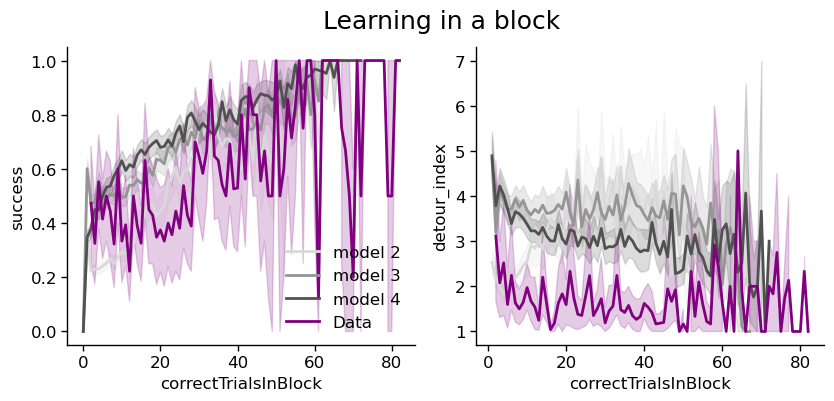

In [230]:
plt.close('all')
fig, axes = plt.subplots(1,2,figsize=(10,4))
colors = sns.color_palette('Greys',3)

sns.lineplot(data=model2_trial30,x='correctTrialsInBlock',y='success', ax=axes[0],label='model 2',color=colors[0])
sns.lineplot(data=model2_trial30.query('success'),x='correctTrialsInBlock',y='detour_index', ax=axes[1],color=colors[0])    

sns.lineplot(data=model3_trial30,x='correctTrialsInBlock',y='success', ax=axes[0],label='model 3',color=colors[1])
sns.lineplot(data=model3_trial30.query('success'),x='correctTrialsInBlock',y='detour_index', ax=axes[1],color=colors[1])    

sns.lineplot(data=model4_trial30,x='correctTrialsInBlock',y='success', ax=axes[0],label='model 4',color=colors[2])
sns.lineplot(data=model4_trial30.query('success'),x='correctTrialsInBlock',y='detour_index', ax=axes[1],color=colors[2])     

sns.lineplot(data=nav_trial,x='correctTrialsInBlock',y='success', ax=axes[0],label='Data',color='purple')
sns.lineplot(data=nav_trial.query('success'),x='correctTrialsInBlock',y='detour_index', ax=axes[1],color='purple')  

sns.despine()

fig.tight_layout(rect=[0.05, 0, 0.9, 0.95])
plt.suptitle('Learning in a block',fontsize=18, y=1)
plt.savefig('Model vs Data Learning cutoff 30.png')

In [174]:
def get_room_accuracy(df):
    delta_dis = df.graph_distance.diff().values[1:]
    delta_dis = np.append(delta_dis,np.nan)
    df['room_accuracy'] = delta_dis==-1
    df.loc[df.minus_step==0,'room_accuracy'] = np.nan
    return df

C:\Users\Admin\AppData\Local\Temp\ipykernel_23468\1493965656.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'nan' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  df.loc[df.minus_step==0,'room_accuracy'] = np.nan
C:\Users\Admin\AppData\Local\Temp\ipykernel_23468\1493965656.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'nan' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  df.loc[df.minus_step==0,'room_accuracy'] = np.nan
C:\Users\Admin\AppData\Local\Temp\ipykernel_23468\1493965656.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'nan' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  df.loc[df.minus_step==0,'room_acc

Text(0.5, 1, 'Correct: Move towards the goal')

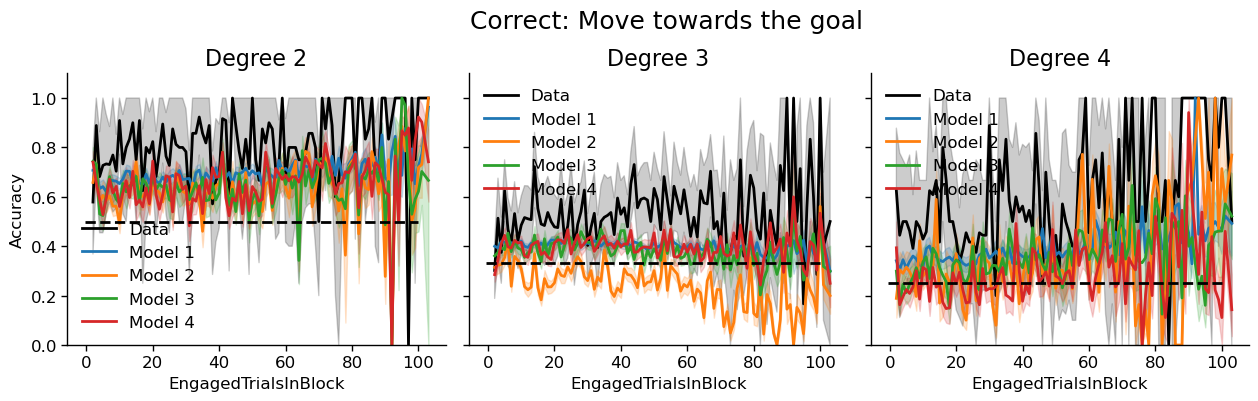

In [451]:
plt.close('all')
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for dd in range(3):
    ax = axes[dd]
    
    a = nav.copy()
    sns.lineplot(data=a[(a.graph_distance>0) & (a.degree==dd+2)],x='EngagedTrialsInBlock',y='room_accuracy',ax=ax,label='Data',color='k')

    a = get_room_accuracy(model1_room30).reset_index(drop=True)
    sns.lineplot(data=a[(a.graph_distance>0) & (a.degree==dd+2)],x='EngagedTrialsInBlock',y='room_accuracy',ax=ax,label='Model 1')
    
    a = get_room_accuracy(model2_room).reset_index(drop=True)
    sns.lineplot(data=a[(a.graph_distance>0) & (a.degree==dd+2)],x='EngagedTrialsInBlock',y='room_accuracy',ax=ax,label='Model 2')

    a = get_room_accuracy(model3_room).reset_index(drop=True)
    sns.lineplot(data=a[(a.graph_distance>0) & (a.degree==dd+2)],x='EngagedTrialsInBlock',y='room_accuracy',ax=ax,label='Model 3')

    a = get_room_accuracy(model4_room).reset_index(drop=True)
    sns.lineplot(data=a[(a.graph_distance>0) & (a.degree==dd+2)],x='EngagedTrialsInBlock',y='room_accuracy',ax=ax,label='Model 4')

    ax.plot([-0.5,100],[1/(dd+2),1/(dd+2)],'k--')
    ax.set_ylim([0,1.1])
    # ax.set_xlim([0.5,6.5])
    ax.set_title(f'Degree {dd+2}',fontsize=16)

    if dd==0:
        ax.set_ylabel('Accuracy')
        
sns.despine()
fig.tight_layout(rect=[0.05, 0, 0.9, 0.95])
plt.suptitle('Correct: Move towards the goal',fontsize=18, y=1)
# plt.savefig('Room accuracy learning cutoff trial specific.png')

C:\Users\Admin\AppData\Local\Temp\ipykernel_23468\1493965656.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'nan' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  df.loc[df.minus_step==0,'room_accuracy'] = np.nan
C:\Users\Admin\AppData\Local\Temp\ipykernel_23468\1493965656.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'nan' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  df.loc[df.minus_step==0,'room_accuracy'] = np.nan
C:\Users\Admin\AppData\Local\Temp\ipykernel_23468\1493965656.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'nan' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  df.loc[df.minus_step==0,'room_acc

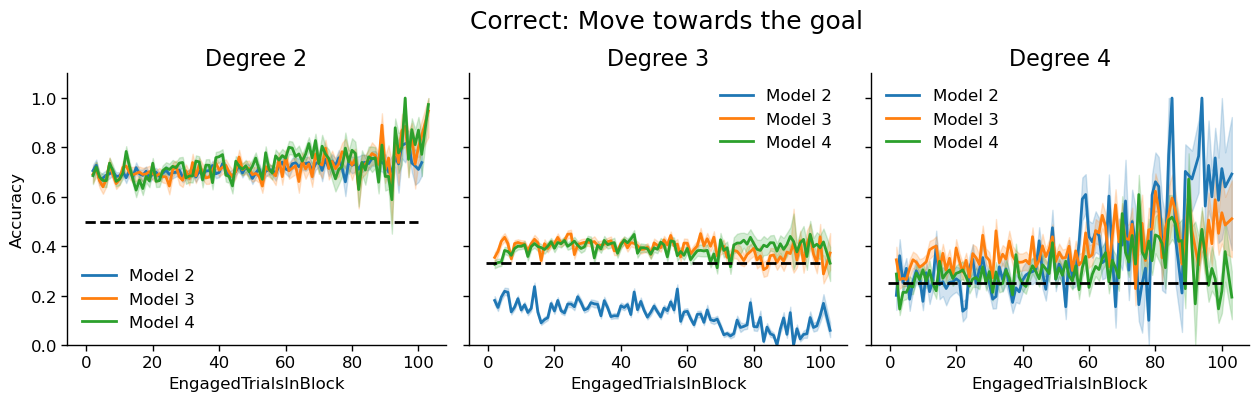

In [193]:
plt.close('all')
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for dd in range(3):
    ax = axes[dd]
    
    a = get_room_accuracy(model2_room30).reset_index(drop=True)
    sns.lineplot(data=a[(a.graph_distance>0) & (a.degree==dd+2)],x='EngagedTrialsInBlock',y='room_accuracy',ax=ax,label='Model 2')

    a = get_room_accuracy(model3_room30).reset_index(drop=True)
    sns.lineplot(data=a[(a.graph_distance>0) & (a.degree==dd+2)],x='EngagedTrialsInBlock',y='room_accuracy',ax=ax,label='Model 3')

    a = get_room_accuracy(model4_room30).reset_index(drop=True)
    sns.lineplot(data=a[(a.graph_distance>0) & (a.degree==dd+2)],x='EngagedTrialsInBlock',y='room_accuracy',ax=ax,label='Model 4')

    ax.plot([-0.5,100],[1/(dd+2),1/(dd+2)],'k--')
    ax.set_ylim([0,1.1])
    # ax.set_xlim([0.5,6.5])
    ax.set_title(f'Degree {dd+2}',fontsize=16)

    if dd==0:
        ax.set_ylabel('Accuracy')
        
sns.despine()
fig.tight_layout(rect=[0.05, 0, 0.9, 0.95])
plt.suptitle('Correct: Move towards the goal',fontsize=18, y=1)
plt.savefig('Room accuracy learning cutoff 30.png')